# Assignment 4: Movie Review Analysis [50 Pt]

In this assignment, we will build a recurrent neural network to work with sequential text data, specificially, movie review data to identify the reviewer sentiment. In the process of completing this assignment, you will:
    
1. Clean and process text data for machine learning.
2. Perform tokenization of text data.
3. Understand and implement a word-level recurrent neural network.
4. Implement batching of text data using a DataLoader before training a recurrent neural network.
5. Understand how to apply pretrained models for transfer learning in natural language processing projects.

### What to submit

Submit an HTML file containing all your code, outputs, and write-up
from parts A and B. You can produce a HTML file directly from Google Colab. The Colab instructions are provided at the end of this document.

**Do not submit any other files produced by your code.**

Include a link to your colab file in your submission.

Please use Google Colab to complete this assignment. If you want to use Jupyter Notebook, please complete the assignment and upload your Jupyter Notebook file to Google Colab for submission.

## Colab Link

Include a link to your Colab file here. If you would like the TA to look at your Colab file in case your solutions are cut off, **please make sure that your Colab file is publicly accessible at the time of submission.**

In [ ]:
# TO BE COMPLETED

https://colab.research.google.com/drive/13ggRLQZt5gT0or4NVoJ3uPGeAclC0ggW?usp=sharing

# PART A - Sentiment Analysis

In this part we will construct a world-level LSTM model for identifying positive and negative reviews. This will be done in a similar way to what was shared in the preparation code for Assignment 4.

In [1]:
# load standard modules/libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# load special modules/libraries
import os
import warnings
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from collections import Counter
import string
import re
from tqdm import tqdm

# load pytorch modules/libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset,DataLoader

warnings.filterwarnings('ignore', category=FutureWarning)



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import  torch
import torchtext

glove = torchtext.vocab.GloVe(name="6B", dim=50)

.vector_cache/glove.6B.zip: 862MB [03:45, 3.83MB/s]                           
100%|█████████▉| 399999/400000 [00:12<00:00, 30835.05it/s]


In [2]:
use_cuda = True and torch.cuda.is_available()
device = torch.device('cuda' if use_cuda else 'cpu')

## Part 1. Data Cleaning [5 pt]

We will be using the "IMDB Movie Review Dataset" provided on the course website. Download "IMDB Dataset.csv" into your Colab workspace.

### Part (i) [1pt EXPLORATORY]

Open up the file in Python, and examine some examples of positive and negative reviews. Comment on the quality of the data and any challenges you foresee in working with these data. Pick one example of a positive review and one of a negative review to support your comments.

In [ ]:
# download IMDB review data

# load dataset
df = pd.read_csv("IMDB Dataset.csv")

# process into data and labels
X = df['review'].values
y = df['sentiment'].values


In [ ]:
# TO BE COMPLETED
print(df.head())


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
positive_reviews = df[df['sentiment'] == 'positive']['review']
negative_reviews = df[df['sentiment'] == 'negative']['review']

print('Positive reviews:\n')
for review in positive_reviews.head():
    print(review)
    print('------')

print('\nNegative reviews:\n')
for review in negative_reviews.head():
    print(review)
    print('------')


Positive reviews:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the sho

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The positive sentiments in some reviews praises aspects like acting, direction, realism, and storyline.
On the contrary, negative reviews highlight flaws in pacing, storyline, acting, and overall entertainment value.

Positive Review Example - "Petter Mattei's 'Love in the Time of Money'"

This review appreciates the visual aesthetics, direction, and acting, highlighting the film's portrayal of human relationships, wealth, and loneliness.
It provides detailed commentary and praises the performances of various actors and thus a comprehensive analysis of the film's strengths
and effectively communicates the reviewer's positive experience.

Negative Review Example - Movie with Jake and the Closet Zombie:

This negative review is critical of the movie's pace and lack of consistency in genre portrayal.
While acknowledging some positive aspects like decent dialogue and acting, the reviewer heavily criticizes the movie's direction and narrative decisions.

Challenges and Data Quality:

Different viewers may have diverse tastes thus leading to contrasting opinions about the same movie or show.
Reviewers use different language, tones, and expressions, which can make sentiment analysis complex. Sarcasm, irony might be challenging
to interpret accurately.

'''


### Part (ii) [1pt EXPLORATORY]

Perform summary statistics on the dataset. What is the average character length of a review? What are the lengths of the longest and shortest reviews?

How many positive reviews and negative reviews are there. Generate a histogram to compare the average character length for positive and negative reviews. Comment on the differences in positive and negative reviews and how that may affect the model you will be using later.

In [ ]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


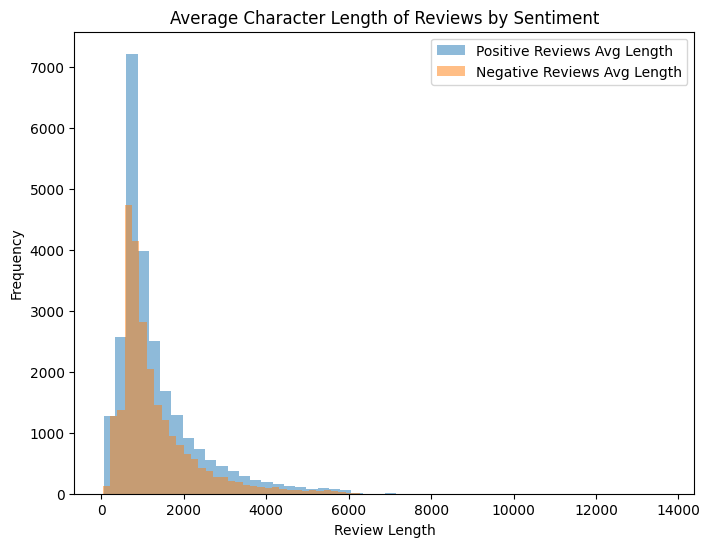


Average character length of a review: 1309.43
Longest review length: 13704
Shortest review length: 32
Number of positive reviews: 25000
Number of negative reviews: 25000


In [ ]:
# TO BE COMPLETED

df['review_length'] = df['review'].apply(len)

# Summary statistics
avg_review_length = df['review_length'].mean()
longest_review_length = df['review_length'].max()
shortest_review_length = df['review_length'].min()

# Counting number of positive and negative reviews
positive_reviews_count = df[df['sentiment'] == 'positive'].shape[0]
negative_reviews_count = df[df['sentiment'] == 'negative'].shape[0]

# Generating histogram for average character length by sentiment
positive_reviews_length = df[df['sentiment'] == 'positive']['review_length']
negative_reviews_length = df[df['sentiment'] == 'negative']['review_length']

plt.figure(figsize=(8, 6))
plt.hist(positive_reviews_length, bins=50, alpha=0.5, label='Positive Reviews Avg Length')
plt.hist(negative_reviews_length, bins=50, alpha=0.5, label='Negative Reviews Avg Length')
plt.title('Average Character Length of Reviews by Sentiment')
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f'\nAverage character length of a review: {avg_review_length:.2f}')
print(f'Longest review length: {longest_review_length}')
print(f'Shortest review length: {shortest_review_length}')
print(f'Number of positive reviews: {positive_reviews_count}')
print(f'Number of negative reviews: {negative_reviews_count}')


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

General observations :
Average character length of a review: 1309.43
Longest review length: 13704
Shortest review length: 32

Observations positive vs negative:

Histogram analysis shows that positive reviews peak around 7000 characters, while negative reviews are more clustered around 5000 characters.
This difference in length can be tricky for the model because longer positive reviews contain a wider range of feelings and ideas.
On the other hand, negative reviews, with their more consistent length, might express dissatisfaction more uniformly.
It's important for the model to handle both short and long reviews well by training it on this mix of lengths.

'''


### Part (iii) [1pt EXPLORATORY]

The following helper code will be used to process the data before we can train our LSTM model. In point form comment on what processing steps are performed in the code provided below and why these steps are necessary or beneficial to training and LSTM.

In [ ]:
X[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [ ]:
def preprocess_string(str1):
    # remove all non-word characters excluding number and letters
    str1= re.sub(r"[^\w\s]",'',str1)
    # remove all whitespace with no space
    str1= re.sub(r"\s",'',str1)
    # replace digits with no space
    str1= re.sub(r"\d",'',str1)
    return str1

def preprocess_sentence(sen1):
    word_list=[]
    stop_word = set(stopwords.words("english"))
    for word in sen1.lower().split():
        word = preprocess_string(word)
        if word not in stop_word and word!='':
            word_list.append(word)
    return word_list

def get_stoi(data):
    word_list=[]
    for review in data:
        word_list.extend(preprocess_sentence(review))
    corpus = Counter(word_list)
    print(corpus.get)
    # sorting on the basis of most common words
    corpus_ =sorted(corpus,key= corpus.get,reverse=True)[:1000]
    # creating a dict
    stoi =  {ch:i+1 for i,ch in enumerate(corpus_)}
    return stoi

def tokenize(data, labels, stoi):
    # tokenize
    data_encoded = []
    for review in data:
        data_encoded.append([stoi[word] for word in preprocess_sentence(review)
                                     if word in stoi.keys()])

    labels_encoded = [1 if label =='positive' else 0 for label in labels]

    return np.array(data_encoded), np.array(labels_encoded)

def padding_(sentences, seq_len):
    features = np.zeros((len(sentences), seq_len),dtype=int)
    for ii, review in enumerate(sentences):
        if len(review)!=0:
            features[ii, -len(review):] = np.array(review)[:seq_len]

    return features

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

preprocess_string() function:

(i)   This function removes all the non-word characters excluding numbers and letters using regular expressions.
(ii)  This function cleans the text data and remove unwanted symbols or special characters that might not contribute to the sentiment analysis task.

preprocess_sentence() function:

(i)   This function converts the input sentence to lowercase and then splits the sentences into words.
(ii)  Follwoing this, it calls the preprocess_string() function to each word to remove non-word characters.
(iii) After removing non-word characters, it checks if the word is a stop word and removes them from the word list if it is a stop word.
(iv)  This function is crucial to filter out the common stop words that do not add much meaning for sentiment analysis.

get_stoi() function:

(i)   This function collects and counts the occurrences of words in the dataset after preprocessing.
(ii)  Following this, it selects the top 1000 most common words from the data and creates a dictionary that maps each word to an integer index.
(iii) This function is necessary to create a vocabulary that the model can use to convert text inputs into numerical representations.
      This reduces the vocabulary size making it computationally efficient.

tokenize() function:

(i)   This function converts or encodes the text data into sequences of integers using the created vocabulary dictionary (stoi).
(ii)  Following this, it also converts the sentiment labels of 'positive' or 'negative' to binary values of 1 or 0.
(iii) This function is essential to convert text data and labels into a format that the LSTM model can process.
      It represents words as integers according to the predefined vocabulary and prepares the target labels for training as the models work better with numericals than strings.

padding_() function:

(i)   This function is used to truncate the sentences or sequences to a fixed length to ensure uniformity in input size.
(ii)  This step is essential for maintaining consistent input dimensions required by the LSTM model, ensuring all sequences have the same length for efficient batch processing.

'''


### Part (iv) [1pt EXPLORATORY]

Split the dataset into `train`, `valid`, and `test`. Use a 60-20-20 split. Then apply the above processing steps to prepare your data for training.

Set the padding of the reviews to 500.

In [ ]:
# TO BE COMPLETED

# Splitting the dataset into train, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(df['review'], df['sentiment'], test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

padding_length = 500

# Getting vocabulary dictionary from training data
stoi_train = get_stoi(X_train)

# Tokenizing and padding the reviews
train_features, train_labels = tokenize(X_train, y_train, stoi_train)
val_features, val_labels = tokenize(X_val, y_val, stoi_train)
test_features, test_labels = tokenize(X_test, y_test, stoi_train)

train_features = padding_(train_features, padding_length)
val_features = padding_(val_features, padding_length)
test_features = padding_(test_features, padding_length)


<built-in method get of Counter object at 0x7af8948aff10>


<ipython-input-12-689f26062728>:40: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(data_encoded), np.array(labels_encoded)


### Part (v) [1pt EXPLORATORY]

Create a DataLoader that will allow you to load the training and validation data in mini-batches. Then generate a dataset of batch size of 16 to verify that the DataLoader works as intended.

In [ ]:
# TO BE COMPLETED

# Creating TensorDatasets for training and validation data
train_dataset = TensorDataset(torch.from_numpy(train_features), torch.from_numpy(train_labels))
val_dataset = TensorDataset(torch.from_numpy(val_features), torch.from_numpy(val_labels))
test_dataset = TensorDataset(torch.from_numpy(test_features), torch.from_numpy(test_labels))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)


for batch_idx, (data, target) in enumerate(train_loader):
    if batch_idx < 1:
        print(f"Training Dataset Batch {batch_idx+1}:")
        print(f"Data shape: {data.shape}")
        print(f"Target shape: {target.shape}\n")

for batch_idx, (data, target) in enumerate(val_loader):
    if batch_idx < 1:
        print(f"Validation Dataset Batch {batch_idx+1}:")
        print(f"Data shape: {data.shape}")
        print(f"Target shape: {target.shape}")



Training Dataset Batch 1:
Data shape: torch.Size([16, 500])
Target shape: torch.Size([16])

Validation Dataset Batch 1:
Data shape: torch.Size([16, 500])
Target shape: torch.Size([16])


## Part 2. Model Building [2pt MODEL]

Build a recurrent neural network model, using an architecture of your choosing. Use one or more fully-connected layers to make the prediction based on your recurrent network output.

Instead of using the RNN output value for the final token, another often used strategy is to max-pool over the entire output array. That is, instead of calling something like:

```
out, _ = self.rnn(x)
self.fc(out[:, -1, :])
```

where `self.rnn` is an `nn.RNN`, `nn.GRU`, or `nn.LSTM` module, and `self.fc` is a
fully-connected
layer, we use:

```
out, _ = self.rnn(x)
self.fc(torch.max(out, dim=1)[0])
```

This works reasonably in practice. An even better alternative is to concatenate the max-pooling and average-pooling of the RNN outputs:

```
out, _ = self.rnn(x)
out = torch.cat([torch.max(out, dim=1)[0],
                 torch.mean(out, dim=1)], dim=1)
self.fc(out)
```

We encourage you to try out all these options. The way you pool the RNN outputs is one of the "hyperparameters" that you can choose to tune later on.

In [ ]:
# TO BE COMPLETED

class SentimentRNN(nn.Module):
    def __init__(self, input_size, hidden_size, model_type: int = 1):
        super(SentimentRNN, self).__init__()

        # TO BE COMPLETED
        if not model_type in [1, 2, 3]:
          raise ValueError('Model type must be 1, 2, or 3')

        self.emb = nn.Embedding.from_pretrained(glove.vectors).to(device)
        self.hidden_size = hidden_size
        self.model_type = model_type

        self.name = f'RNN_Model{model_type}_Hidden{hidden_size}'
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True).to(device)
        self.fc = nn.Linear(hidden_size, 2).to(device)


    def forward(self, x):

        # TO BE COMPLETED

        x = torch.stack([i.to(device).long() for i in x])
        # Look up the embedding
        x = self.emb(x)
        # Set an initial hidden state
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(device)
        # Forward propagate the RNN
        out, _ = self.rnn(x, h0)

        if self.model_type == 1:
            out = out[:, -1, :]

        elif self.model_type == 2:
            out = torch.max(out, dim=1)[0]

        else:
            out = torch.cat([torch.max(out, dim=1)[0], torch.mean(out, dim=1)], dim=1)

        return self.fc(out)


## Part 3. Training [3 pt]

### Part (i) [1pt MODEL]

Complete the `get_accuracy` function, which will compute the
accuracy (rate) of your model across a dataset (e.g. validation set).

In [ ]:
def get_accuracy_loss(model, data_loader, criterion):
    """ Compute the accuracy of the `model` across a dataset `data`

    Example usage:

    >>> model = MyRNN() # to be defined
    >>> get_accuracy(model, valid_loader) # the variable `valid_loader` is from above
    """

    # TO BE COMPLETED
    correct, total, total_loss, i = 0, 0, 0, 0

    for data, labels in data_loader:

        data = data.to(device)
        labels = labels.to(device)

        output = model(data)
        pred = output.max(1, keepdim=True)[1]

        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += labels.shape[0]

        loss = criterion(output, labels)
        total_loss += loss.item()
        i += 1

    loss = float(total_loss) / (i)
    acc = correct / total

    return loss, acc



### Part (ii) [1pt MODEL]

Train your model. Plot the training curve of your final model.
Your training curve should have the training/validation loss and
accuracy plotted periodically.

In [ ]:
# TO BE COMPLETED

def train_rnn_network(model, train, valid, batch_size= 16, num_epochs=10, learning_rate=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    train_loss, valid_loss, train_acc, valid_acc = [], [], [], []
    epochs = []

    for epoch in range(num_epochs):

        print('\nEpoch {}/{}'.format(epoch+1, num_epochs))
        print('-' * 10)

        for data, labels in train:

            data = data.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            pred = model(data)
            loss = criterion(pred, labels)
            loss.backward()
            optimizer.step()

        tr_loss, tr_acc = get_accuracy_loss(model, train, criterion)

        with torch.no_grad():
          val_loss, val_acc = get_accuracy_loss(model, valid, criterion)

        epochs.append(epoch)
        train_loss.append(tr_loss)
        train_acc.append(tr_acc)
        valid_loss.append(val_loss)
        valid_acc.append(val_acc)

        print("Epoch %d; Loss %f; Train Acc %f; Val Acc %f" % (epoch+1, loss, train_acc[-1], valid_acc[-1]))

    plt.title("Training/Validation Loss")
    plt.plot(train_loss, label="Train")
    plt.plot(valid_loss, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc="best")
    plt.show()

    plt.title("Training/Validation Accuracy")
    plt.plot(epochs, train_acc, label="Train")
    plt.plot(epochs, valid_acc, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.show()



Epoch 1/10
----------
Epoch 1; Loss 0.673097; Train Acc 0.514367; Val Acc 0.516700

Epoch 2/10
----------
Epoch 2; Loss 0.696464; Train Acc 0.526767; Val Acc 0.513500

Epoch 3/10
----------
Epoch 3; Loss 0.700251; Train Acc 0.542867; Val Acc 0.525800

Epoch 4/10
----------
Epoch 4; Loss 0.825171; Train Acc 0.534900; Val Acc 0.524300

Epoch 5/10
----------
Epoch 5; Loss 0.768056; Train Acc 0.507100; Val Acc 0.515700

Epoch 6/10
----------
Epoch 6; Loss 0.695723; Train Acc 0.532500; Val Acc 0.544700

Epoch 7/10
----------
Epoch 7; Loss 0.786878; Train Acc 0.509233; Val Acc 0.515900

Epoch 8/10
----------
Epoch 8; Loss 0.658321; Train Acc 0.530833; Val Acc 0.525200

Epoch 9/10
----------
Epoch 9; Loss 0.587087; Train Acc 0.523267; Val Acc 0.527300

Epoch 10/10
----------
Epoch 10; Loss 0.815523; Train Acc 0.510700; Val Acc 0.516600


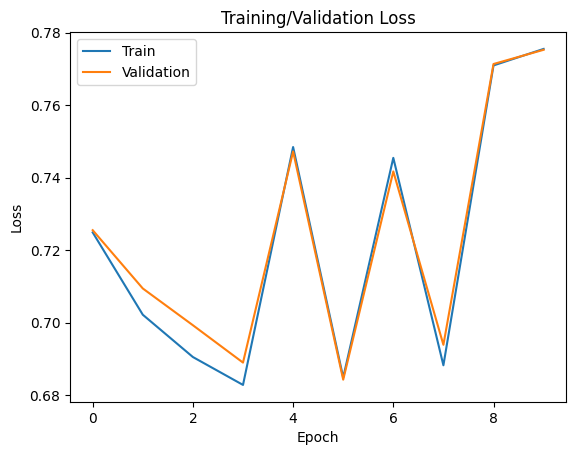

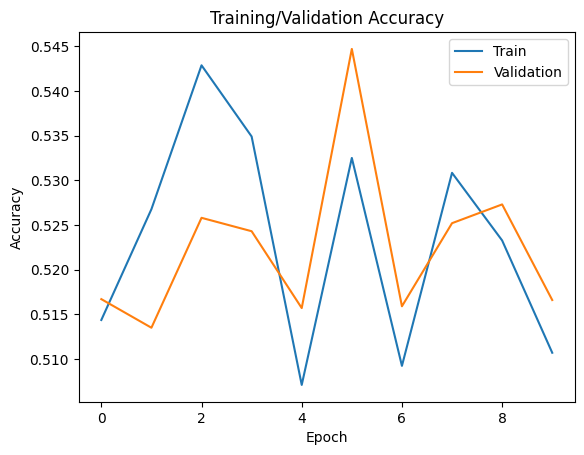

In [ ]:
model = SentimentRNN(50, 50, 1)
hyper_parameters = dict(batch_size=16, num_epochs= 10, learning_rate=0.01)
train_rnn_network(model, train_loader, val_loader, ** hyper_parameters)

### Part (iii) [1pt MODEL]

Choose at least 4 hyperparameters to tune. Explain how you tuned the hyperparameters.
You don't need to include your training curve for every model you trained.
Instead, explain what hyperparemters you tuned, what the best validation accuracy was,
and the reasoning behind the hyperparameter decisions you made.

For this assignment, you should tune more than just your learning rate and epoch.
Choose at least 2 hyperparameters that are unrelated to the optimizer.

Learning rate: 0.001

After testing with different learning rates, 0.001 was found to be the best learning rate for the model.


Epoch 1/10
----------
Epoch 1; Loss 0.676575; Train Acc 0.550133; Val Acc 0.542200

Epoch 2/10
----------
Epoch 2; Loss 0.665387; Train Acc 0.570600; Val Acc 0.558000

Epoch 3/10
----------
Epoch 3; Loss 0.713218; Train Acc 0.538400; Val Acc 0.525300

Epoch 4/10
----------
Epoch 4; Loss 0.689786; Train Acc 0.533300; Val Acc 0.531600

Epoch 5/10
----------
Epoch 5; Loss 0.739524; Train Acc 0.539367; Val Acc 0.524900

Epoch 6/10
----------
Epoch 6; Loss 0.638228; Train Acc 0.564733; Val Acc 0.555600

Epoch 7/10
----------
Epoch 7; Loss 0.639597; Train Acc 0.584133; Val Acc 0.577200

Epoch 8/10
----------
Epoch 8; Loss 0.642240; Train Acc 0.590700; Val Acc 0.581800

Epoch 9/10
----------
Epoch 9; Loss 0.641714; Train Acc 0.620100; Val Acc 0.600100

Epoch 10/10
----------
Epoch 10; Loss 0.842472; Train Acc 0.634400; Val Acc 0.618100


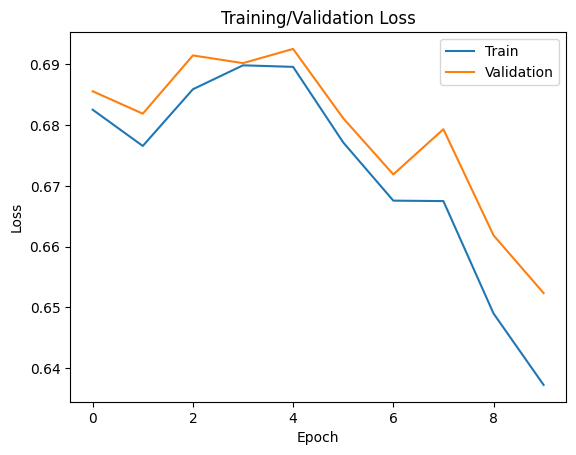

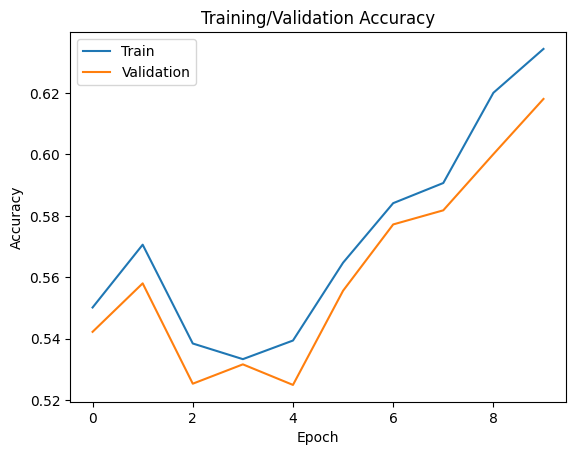

In [ ]:
# TO BE COMPLETED
model= SentimentRNN(50, 50, 1)
hyper_parameters = dict(batch_size=16, num_epochs= 10, learning_rate=0.001)
train_rnn_network(model, train_loader, val_loader, ** hyper_parameters)


Batch Size: 64

After testing with different batch sizes, 64 was found to be the best batch size for the model.


Epoch 1/10
----------
Epoch 1; Loss 0.713111; Train Acc 0.583400; Val Acc 0.572200

Epoch 2/10
----------
Epoch 2; Loss 0.710989; Train Acc 0.596100; Val Acc 0.582300

Epoch 3/10
----------
Epoch 3; Loss 0.662010; Train Acc 0.612167; Val Acc 0.595400

Epoch 4/10
----------
Epoch 4; Loss 0.617072; Train Acc 0.608200; Val Acc 0.598800

Epoch 5/10
----------
Epoch 5; Loss 0.619565; Train Acc 0.624000; Val Acc 0.606600

Epoch 6/10
----------
Epoch 6; Loss 0.616934; Train Acc 0.566500; Val Acc 0.550000

Epoch 7/10
----------
Epoch 7; Loss 0.653365; Train Acc 0.571900; Val Acc 0.556500

Epoch 8/10
----------
Epoch 8; Loss 0.595942; Train Acc 0.644600; Val Acc 0.627300

Epoch 9/10
----------
Epoch 9; Loss 0.549032; Train Acc 0.615233; Val Acc 0.601800

Epoch 10/10
----------
Epoch 10; Loss 0.599021; Train Acc 0.654700; Val Acc 0.649900


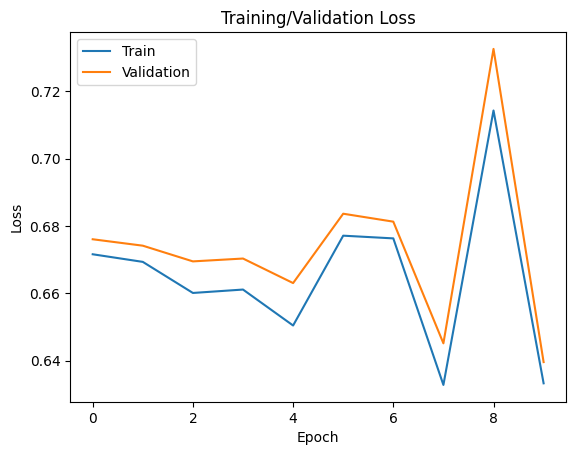

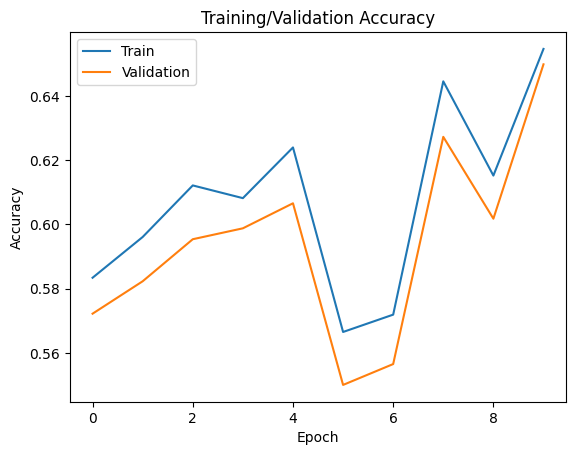

In [ ]:
model = SentimentRNN(50, 50, 1)
hyper_parameters = dict(batch_size=64, num_epochs= 10, learning_rate=0.001)
train_rnn_network(model, train_loader, val_loader, ** hyper_parameters)


Hidden Size: 100

After testing with different hidden sizes, 100 was found to be the best hidden size for the model.


Epoch 1/10
----------
Epoch 1; Loss 0.785592; Train Acc 0.589900; Val Acc 0.579000

Epoch 2/10
----------
Epoch 2; Loss 0.671141; Train Acc 0.506633; Val Acc 0.513000

Epoch 3/10
----------
Epoch 3; Loss 0.732072; Train Acc 0.529433; Val Acc 0.532200

Epoch 4/10
----------
Epoch 4; Loss 0.707815; Train Acc 0.589633; Val Acc 0.576400

Epoch 5/10
----------
Epoch 5; Loss 0.706237; Train Acc 0.547067; Val Acc 0.550300

Epoch 6/10
----------
Epoch 6; Loss 0.705514; Train Acc 0.584067; Val Acc 0.575000

Epoch 7/10
----------
Epoch 7; Loss 0.633027; Train Acc 0.591433; Val Acc 0.582400

Epoch 8/10
----------
Epoch 8; Loss 0.734633; Train Acc 0.604767; Val Acc 0.590400

Epoch 9/10
----------
Epoch 9; Loss 0.596581; Train Acc 0.598300; Val Acc 0.588000

Epoch 10/10
----------
Epoch 10; Loss 0.683767; Train Acc 0.525533; Val Acc 0.531800


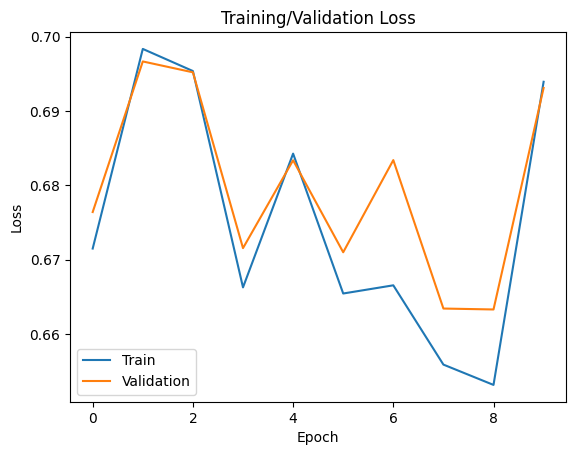

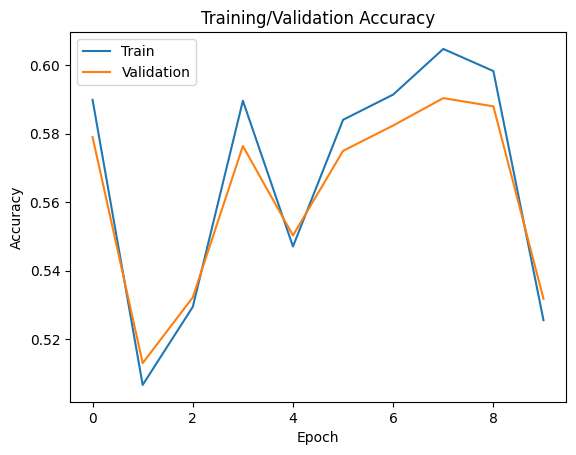

In [ ]:
model = SentimentRNN(50, 100, 1)
hyper_parameters = dict(batch_size=64, num_epochs= 10, learning_rate=0.001)
train_rnn_network(model, train_loader, val_loader, ** hyper_parameters)


Model Type: 2

After testing with different model types based on different pooling of the RNN outputs, model type 2 was found to be the best for the model.


Epoch 1/10
----------
Epoch 1; Loss 0.411944; Train Acc 0.774433; Val Acc 0.764900

Epoch 2/10
----------
Epoch 2; Loss 0.536811; Train Acc 0.815833; Val Acc 0.793400

Epoch 3/10
----------
Epoch 3; Loss 0.829949; Train Acc 0.809300; Val Acc 0.791800

Epoch 4/10
----------
Epoch 4; Loss 0.489498; Train Acc 0.842100; Val Acc 0.809000

Epoch 5/10
----------
Epoch 5; Loss 0.396981; Train Acc 0.836400; Val Acc 0.797700

Epoch 6/10
----------
Epoch 6; Loss 0.205000; Train Acc 0.851200; Val Acc 0.811900

Epoch 7/10
----------
Epoch 7; Loss 0.250324; Train Acc 0.869500; Val Acc 0.815400

Epoch 8/10
----------
Epoch 8; Loss 0.276217; Train Acc 0.848000; Val Acc 0.802900

Epoch 9/10
----------
Epoch 9; Loss 0.250823; Train Acc 0.877433; Val Acc 0.802800

Epoch 10/10
----------
Epoch 10; Loss 0.421139; Train Acc 0.871800; Val Acc 0.793200


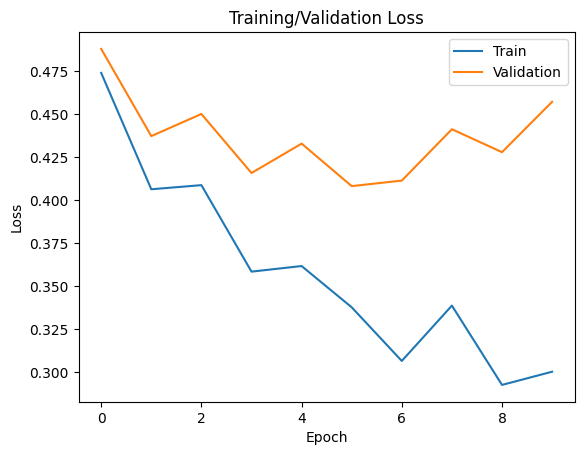

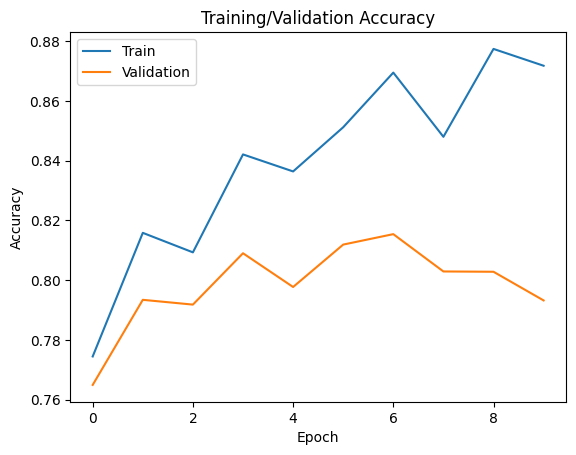

In [ ]:
model = SentimentRNN(50, 100, 2)
hyper_parameters = dict(batch_size=64, num_epochs= 10, learning_rate=0.001)
train_rnn_network(model, train_loader, val_loader, ** hyper_parameters)


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The hyperparameters selected for tuning are:

Learning rate: We were able to observe that after a point when the learning rate drops, the model fails to learn or learns very slowly.
This can be because of very small gradient steps or vanishing gradients. Our best learning rate was 0.001.
Best Validation Accuracy: 0.6181

Batch size: Ierations were conducted to determine a best combination of learning rate and batch size.
Lower batch size requires lower learning rates for attaining stability in the model training process. Conversely, higher batch sizes allows for higher learning rates. Best Batch Size: 64
Best Validation Accuracy: 0.6499

Hidden size: Hidden size is a hyperparameter of the model architecture. The higher hidden size is beneficial in order to extract useful features from the dataset. Best Hidden Size: 100
Best Validation Accuracy: 0.5318

Model type: The way we pool the RNN outputs forms one of the hyperparameters changing the model type. Different models have different ways in which the output is extracted from the network.
Best Model type: Model 2.
Best Validation Accuracy: 0.7932

'''

## Part 4. Evaluation [10 pt]

**Important**. At this point in the assignment your test data should not have been evaluated by any of your models. The test data should be evaluated only after you have finished all the previous parts of the assignment. Once you evaluate your models on the test data you cannot change your models or else you may make hyperparameter adjustments that could lead to overfitting to the test data.

### Part (i) [3pt RESULT]

Report the final test accuracy of your model. Comment on how the result compares with accuracy obtained on the training and validation data. Are the results what you expected? Explain.

In [ ]:
# TO BE COMPLETED

criterion = nn.CrossEntropyLoss()
loss_test, accuracy_test = get_accuracy_loss(model, test_loader, criterion)
print('The final test accuracy of the best model:', accuracy_test)


The final test accuracy of the best model: 0.7992


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The final test accuracy of the best model is 0.7992
The accuracy obtained on the training data is 0.8718.
The accuracy obtained on the validation data is 0.7932.

The final test accuracy of the model is comparable to the accuracy on the validation data. The results obtained are expected as the model
usually performs well on the training set, and there is always a slight drop in accuracy on both the validation and test set.
The similarity between the validation and test accuracies suggests that the model is able to generalize to unseen data to some extent.

'''


### Part (ii) [3pt DISCUSSION]

Look over the misclassified samples in the test data and see if you can find any patterns on where the model has difficulty with identifying the review sentiment. Provide up to 5 examples of positive and negative reviews each to support your findings.

In [ ]:
def indices_to_text(indices, stoi):
  return ' '.join([word for index in indices for word, idx in stoi.items() if idx == index])

misclassified_positive = []
misclassified_negative = []

model.eval()

with torch.no_grad():
  for data, labels in test_loader:
    data = data.to(device)
    labels = labels.to(device)
    outputs = model(data)
    _, preds = torch.max(outputs, 1)
    misclassified_mask = preds != labels
    misclassified_indices = torch.nonzero(misclassified_mask).squeeze(dim=1)

    for mis_idx in misclassified_indices:
      input_text = indices_to_text(data[mis_idx].cpu().numpy(), stoi_train)
      true_label = labels[mis_idx].item()
      predicted_label = preds[mis_idx].item()

      if true_label == 1 and len(misclassified_positive) < 5:
        misclassified_positive.append((input_text, true_label, predicted_label))
      elif true_label == 0 and len(misclassified_negative) < 5:
        misclassified_negative.append((input_text, true_label, predicted_label))

      if len(misclassified_positive) >= 5 and len(misclassified_negative) >= 5:
        break

print("Misclassified Positive Reviews:\n")
for sample in misclassified_positive:
  input_text, true_label, predicted_label = sample
  print(f'True Label: {true_label}, Predicted Label: {predicted_label}')
  print(f'Misclassified Text: {input_text}\n')

print("Misclassified Negative Reviews:\n")
for sample in misclassified_negative:
  input_text, true_label, predicted_label = sample
  print(f'True Label: {true_label}, Predicted Label: {predicted_label}')
  print(f'Misclassified Text: {input_text}\n')



Misclassified Positive Reviews:

True Label: 1, Predicted Label: 0
Misclassified Text: saw first nearly long fan night turned modern dream come true br plot basically follows original storyline means dont want even try plot probably cover imagine girl guy school think possible would create even question plot reality point filmbr br though absolutely hilarious nearly every scene writers director actors br star film shes comedy much going films public life like many today im least one decent young actress left hollywood ok im br hes hot like really makes laugh scenes whole movie hes trying first talking later br rest cast either characters mother classic evil br overall lots fun laughs highly cast maybe original modern plays including things hate

True Label: 1, Predicted Label: 0
Misclassified Text: enjoy watching people especially well best scenes movie takes called especially christmas time also appears br even old film even tv state movie big screen went check much enjoyable big scre

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

After going through the misclassified reviews we can see that the model is struggling due to various reasons.
One of them is the ambiguity in sentiment expression where some reviews exhibit a mix of positive and negative sentiments as well as they include ambiguous phrases
that could be interpreted differently, leading to misclassification.

Furthermore, we can see that these reviews are in fact complex Sentences and its phrasing could confuse the model, making it challenging to correctly identify the sentiment.

One example for Misclassified Positive Review: though absolutely hilarious nearly every scene writers director actors br star film shes comedy much going films public life
like many today im least one decent young actress left hollywood ok im br hes hot like really makes laugh scenes whole movie hes trying first talking later br rest cast either
characters mother classic evil overall lots fun laughs highly cast maybe original modern plays including things hate.


'''


### Part (iii) [2pt RESULT]

What is your model's prediction of the **probability** that
the review message provided below is a positive review?

Hint: You will need to apply the same processing on the review as was done on the the train, val, and test data sets.

In [ ]:
review = """ Man.... I wish I loved this movie more than I did. Don't get me wrong,
it's a solid action movie with jaw-dropping stunts (some of the best in the series),
but as a Mission: Impossible movie, it felt like a small step backward for the franchise.
Fallout had mind-blowing action sequences and stunt work, along with developing Ethan's
relationship with Ilsa, providing closure with Julia, showing the lengths Ethan would
go to protect those closest to him, and battling an imposing villain. Dead Reckoning:
Part One stretches the movie across two films only to seemingly showcase action
spectacle after action spectacle while sacrificing character development.
Characters I have grown to love over a decade of films felt sidelined, ignored,
or wasted. Hayley Atwell's new character chewed up most of the screen time, and
while she was fantastic, I wanted to see more of the original team. The new villain
had an inconsistent ability that confused more than intimidated. There were some
important emotional moments that I just didn't feel the weight of when I definitely
should have. Part Two might tie everything together and make me enjoy Part One
more in retrospect, but unfortunately, I left wanting more from this one. """



In [ ]:
# TO BE COMPLETED

def process(data, stoi, seq_length):

  tokenize_review= [stoi[word] for word in preprocess_sentence(review) if word in stoi.keys()]
  padded_review= np.zeros(seq_length,dtype=int)
  if len(review)!=0:
    padded_review[-len(tokenize_review):] = np.array(tokenize_review)[:seq_length]
  return padded_review

processed_review = process(review, stoi_train, seq_length=500)
input_tensor = torch.tensor(processed_review).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
  output = model(input_tensor)

output_values = output[0].cpu().numpy() #Changing to cpu as numpy is predominantly performed with cpu
probs = F.softmax(torch.tensor(output_values), dim=0)
probability = float(probs[1])

print("Probability of Positive Review:", probability)


Probability of Positive Review: 0.41303345561027527


### Part (iv) [2pt DISCUSSION]

Do you think that detecting positive and negative reviews is an easy or difficult task?

Since machine learning models are expensive to train and deploy, it is very
important to compare our models against baseline models: a simple
model that is easy to build and inexpensive to run that we can compare our
recurrent neural network model against.

Explain how you might build a simple baseline model. This baseline model
can be a simple neural network (with very few weights), a hand-written algorithm,
or any other strategy that is easy to build and test.

**Do not actually build a baseline model. Instead, provide instructions on
how to build it.**

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

Instructions to build a baseline model:

Data Processing: Pre-process the dataset by removing stop words, stemming, special characters etc and converting all the text into lowercase.
Splitting the Dataset: Split the preprocessed dataset into training, validation and test sets.
Define the Classifier: Use the scikit-learn library to define any easy-to-implement classifier.
Train the Model: Train the classifier on the preprocessed training dataset to learn the joint probability distribution of the dataset.
Tune the Model: Tune the hyperparameters to find the best combination that makes the model click.
Test the Model: Test the predictions of the trained model on the preprocessed testing dataset.

'''

# PART B - Transfer Learning

For many natural language processing tasks, it is generally not a good idea to train a very large deep neural network model from scratch due to enormous compute requirements and lack of sufficient amounts of training data. Instead, you should always try to take advantage of an existing model that performs similar tasks as the one you need to solve.

In this part of the assignment we will be using pretrained models to improve the performance on identifying positive and negative reviews. There are several pretrained models that are available to us, here we will use a pretrained BERT model that comes with the hugging face transformer library.

Provided below is sample code to get you started. For more details please visit the hugging face tutorial on using pretrained models using PyTorch: https://huggingface.co/docs/transformers/training

#### Sample Code

In [3]:
# install relevant libraries
!pip install -qq transformers

In [4]:
# load relevant libraries
import transformers
from transformers import BertModel, BertTokenizer, AdamW, get_linear_schedule_with_warmup

PRE_TRAINED_MODEL_NAME = 'bert-base-cased'

tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)
bert_model = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)


tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [5]:
sample_txt = 'I want to learn how to do sentiment analysis using BERT and tokenizer.'

encoding = tokenizer.encode_plus(
  sample_txt,
  max_length=32,
  add_special_tokens=True, # Add '[CLS]' and '[SEP]'
  return_token_type_ids=False,
  pad_to_max_length=True,
  return_attention_mask=True,
  return_tensors='pt',  # Return PyTorch tensors
  truncation = True
)

In [6]:
encoding['input_ids']

tensor([[  101,   146,  1328,  1106,  3858,  1293,  1106,  1202, 17024,  3622,
          1606,   139,  9637,  1942,  1105, 22559, 17260,   119,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0]])

In [7]:
encoding['attention_mask']

tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])

In [8]:
hidden_states = bert_model(input_ids=encoding['input_ids'],
                           attention_mask=encoding['attention_mask'])[0]
pooled_output = bert_model(input_ids=encoding['input_ids'],
                           attention_mask=encoding['attention_mask'])[1]

In [9]:
hidden_size = bert_model.config.hidden_size

print(hidden_size)
print(hidden_states.shape)
print(pooled_output.shape)


768
torch.Size([1, 32, 768])
torch.Size([1, 768])


In the sample code provided we loaded a short text sequence, tokenized it using the same tokenization that was used in the pretrained BERT model, and fed the tokenized input into the BERT model to obtain the embeddings.

The model output consists of two forms of embeddings:
- **hidden_states** are the final layer of outputs that has a shape sequence_length x embeddings, much like the hidden states of a recurrent neural network
- **pooled_output** is the result of applying max pooling on the hidden states to effectively collapse the sequence dimenension and ensure the same output size for any given sequence before feeding into the classification stage

Note that you can preprocess all of the data prior to training a classifier stage for sentiment analysis to help speed up the training process. This is no different from the process we applied in an earlier assignment using AlexNet and image data.

## Part 1. Data Loading [5 pt]

We will be using the same "IMDB Movie Review Dataset" that we used earlier. Reload the data and complete Part B of the assignment. You should be able to complete part B independently from Part A.

### Part (i) [1pt EXPLORATORY]

Provided below is a DataLoader for your training and test datasets so you can iterate over batches of data. Run the DataLoader to create your training, validation, and test data.

In [10]:
from torch.utils.data import Dataset, DataLoader

class MovieReviewDataset(Dataset):

  def __init__(self, reviews, targets, tokenizer, max_len):
    self.reviews = reviews
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.reviews)

  def __getitem__(self, item):
    review = str(self.reviews[item])
    target = 1 if self.targets[item] == 'positive' else 0

    encoding = self.tokenizer.encode_plus(
      review,
      add_special_tokens=True,
      max_length=self.max_len,
      return_token_type_ids=False,
      pad_to_max_length=True,
      return_attention_mask=True,
      return_tensors='pt',
      truncation = True
    )

    return {
      'review_text': review,
      'input_ids': encoding['input_ids'].flatten(),
      'attention_mask': encoding['attention_mask'].flatten(),
      'targets': torch.tensor(target, dtype=torch.long)
    }

In [11]:
df_bert = pd.read_csv("IMDB Dataset.csv")
X = df_bert['review'].values
y = df_bert['sentiment'].values

In [12]:
df_bert

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [13]:
def preprocess_string(text):
    # Removing rows which have no non-whitespace characters
    if len(text.strip()) == 0:
        return None

    # Convert text to lowercase
    text = text.lower()

    # Remove unwanted patterns (non-word characters excluding numbers and letters)
    text = re.sub(r"[^\w\s]", '', text)

    # Replace digits with no space
    text = re.sub(r"\d", '', text)

    return text


# Applying preprocess_string function to the DataFrame

df_bert['review'] = df_bert['review'].apply(preprocess_string)
df_bert.dropna(subset=['review'], inplace=True)

In [14]:
df_bert

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production br br the filmin...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically theres a family where a little boy j...,negative
4,petter matteis love in the time of money is a ...,positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,bad plot bad dialogue bad acting idiotic direc...,negative
49997,i am a catholic taught in parochial elementary...,negative
49998,im going to have to disagree with the previous...,negative


In [15]:
# Splitting the dataset into train, validation, and test using a 60-20-20 split
df_train_val, df_test = train_test_split(df_bert, stratify = df_bert['sentiment'], test_size = 0.2, random_state = 42)
df_train, df_val = train_test_split(df_train_val, stratify = df_train_val['sentiment'], test_size = 0.25, random_state = 42)


In [16]:
# prepare data loaders

def get_dataloaders(batch_size=16, MAX_LEN=50):

  #training data
  train_data = MovieReviewDataset(reviews=df_train['review'].to_numpy(),
                                targets=df_train['sentiment'].to_numpy(),
                                tokenizer=tokenizer,
                                max_len=MAX_LEN)

  train_data_loader = DataLoader(train_data, batch_size = batch_size, num_workers = 2)

  #validation data
  val_data = MovieReviewDataset(reviews=df_val['review'].to_numpy(),
                                targets=df_val['sentiment'].to_numpy(),
                                tokenizer=tokenizer,
                                max_len=MAX_LEN)

  val_data_loader = DataLoader(val_data, batch_size = batch_size, num_workers = 2)

  #test data
  test_data = MovieReviewDataset(reviews=df_test['review'].to_numpy(),
                                targets=df_test['sentiment'].to_numpy(),
                                tokenizer=tokenizer,
                                max_len=MAX_LEN)

  test_data_loader = DataLoader(test_data, batch_size = batch_size, num_workers = 2)

  return train_data_loader, val_data_loader, test_data_loader


train_loader_bert, val_loader_bert, test_loader_bert = get_dataloaders(16)


### Part (ii) [1pt EXPLORATORY]

Use the **train_data_loader** to load one sample. What are the different attributes provided with the sample and how are they used?

In [17]:
# TO BE COMPLETED

data_iter = iter(train_loader_bert)
sample = next(data_iter)
print('The different attributes provided in the sample are', sample.keys())


The different attributes provided in the sample are dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])


In [18]:
print('The Review_text attribute:',sample['review_text'],'\n')
print('The Input_ids attribute:',sample['input_ids'],'\n')
print('The Attention_mask attribute:',sample['attention_mask'],'\n')
print('The Targets attribute:',sample['targets'],'\n')

The Review_text attribute: ['the shining you know whats weird about this movie this is the movie that everyone for people who claim to not like horror films will always say that the shining is a terrific film this is stanley kubricks classic vision of stephen kings horror tale of madness and blood this is just an incredible film and wither you have seen it or not you have heard of it know a few lines from it and know some of the classic images who could forget jacks heres johnny who could forget all work and no play make jack a dull boy who could forget that chilling ending this is the film that is unforgettable and honestly in my opinion is kubricks best work i know there is a lot of argument in that department a lot of people say its  a space odyssey or clockwork orange or even dr strangelove but if those film pioneered film making then the shining perfected it this is the tale of isolation madness terrifying images and the ultimate ghost story that will crawl underneath your skin br

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The different attributes provided in the sample are 'review_text', 'input_ids', 'attention_mask', 'targets'.
review_text represents the actual text of the movie review.
input_ids are tokenized ids generated from the review text using a tokenizer. Tokenization breaks down the text into smaller units, and converts them into numerical ids understandable by the model.
Attention mask indicates which parts of the tokenized input should be given attention by the model during processing.
targets represents the target sentiment label associated with the review.


'''

### Part (iii) [1pt EXPLORATORY]

Determine the range of values for the tokens in the training data. How are the tokens obtained?

Hint: You can apply your intuition here, or do some additional research to find how the "bert-base-cased" tokenization is done.

In [19]:
# TO BE COMPLETED
token_ids = sample['input_ids']

min_token_id = token_ids.min().item()
max_token_id = token_ids.max().item()

print(f"Minimum Token ID: {min_token_id}")
print(f"Maximum Token ID: {max_token_id}")
print(f"The range of values for the tokens are from {min_token_id} to {max_token_id}")


Minimum Token ID: 101
Maximum Token ID: 28028
The range of values for the tokens are from 101 to 28028


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The range of values for the tokens are from 101 to 28028.

In BERT-base-cased tokenization, tokens are obtained through subword tokenization, breaking words into subword units based on a predefined vocabulary.
This process retains casing information and generates a unique numerical ID for each token, allowing the model to process text by representing it as a sequence of token embeddings.


'''

### Part (iv) [1pt EXPLORATORY]

Generate histograms of all the token values in the training data. Repeat for the validation and test data. What are the top 5 occuring tokens in the training_dataset? What do these tokens represent?

In [20]:
# TO BE COMPLETED

from collections import Counter

def get_tokenids(loader):

    token_ids_flat = []

    for batch in loader:
        token_ids = batch['input_ids']
        token_ids_flat.extend(token_ids.flatten().tolist())

    return token_ids_flat

def hist(tokenids, str):

  token_counts = Counter(tokenids)
  top_5_tokens = token_counts.most_common(5)

  plt.hist(tokenids, bins=50, alpha=0.70, color='Blue')
  plt.xlabel('Token Values')
  plt.ylabel('Count')
  plt.title('Histogram of Token Values in {} Data'.format(str))
  plt.show()
  return top_5_tokens


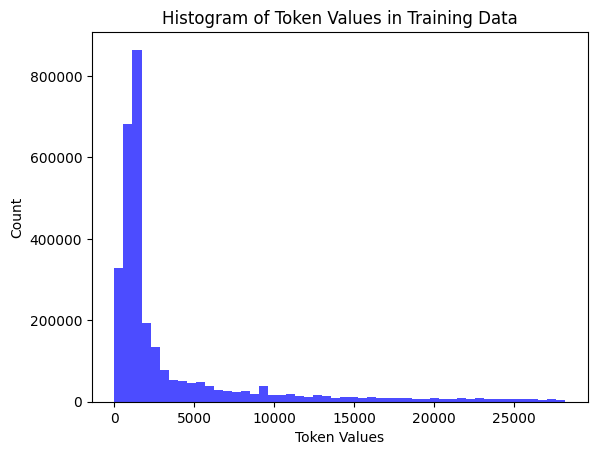

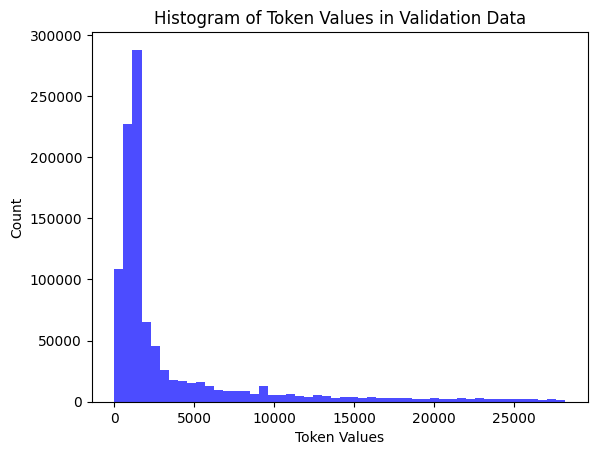

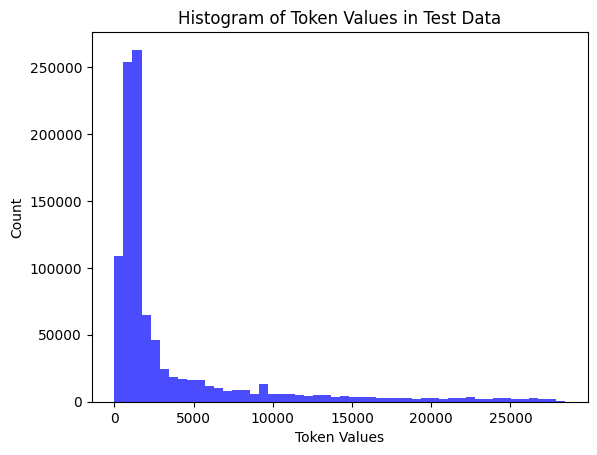

In [ ]:
token_ids_train_flat = get_tokenids(train_loader_bert)
token_ids_val_flat = get_tokenids(val_loader_bert)
token_ids_test_flat = get_tokenids(test_loader_bert)

top_5_tokens_training= hist(token_ids_train_flat, "Training")
top_5_tokens_val= hist(token_ids_val_flat, "Validation")
top_5_tokens_test= hist(token_ids_test_flat, "Test")

In [ ]:
# Top 5 tokens and what they represent
print('Top 5 occuring tokens in Training dataset are:')
for i, j in top_5_tokens_training:
  word = tokenizer.decode(i)
  print(f'Token Value: {i}, Count: {j}, Corresponding word: {word}')


Top 5 occuring tokens in Training dataset are:
Token Value: 1103, Count: 138707, Corresponding word: t h e
Token Value: 0, Count: 79233, Corresponding word: [ P A D ]
Token Value: 170, Count: 74074, Corresponding word: a
Token Value: 1105, Count: 66465, Corresponding word: a n d
Token Value: 1104, Count: 62423, Corresponding word: o f


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

Top 5 occuring tokens in Training dataset are:
Token Value: 1103, Count: 138707, Corresponding word: t h e
Token Value: 0, Count: 79233, Corresponding word: [ P A D ]
Token Value: 170, Count: 74074, Corresponding word: a
Token Value: 1105, Count: 66465, Corresponding word: a n d
Token Value: 1104, Count: 62423, Corresponding word: o f

Each unique integer token value corresponds to a specific word or subword in the vocabulary.

'''

### Part (v) [1pt EXPLORATORY]

Select a single sample from your training DataLoader and feed it through the **bert_model** to obtain the hidden_states and pooled_output. Briefly describe what each tensor dimension represents and what affects the size of each dimension.

In [21]:
# TO BE COMPLETED

input_ids = sample['input_ids']
attention_mask = sample['attention_mask']

output = bert_model(input_ids=input_ids, attention_mask=attention_mask)

hidden_states = output[0]
pooled_output = output[1]

print('Dimension of hidden_states:', hidden_states.shape)
print('Dimension of pooled_output:', pooled_output.shape)



Dimension of hidden_states: torch.Size([16, 50, 768])
Dimension of pooled_output: torch.Size([16, 768])


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

Hidden States:

The first dimension (16) refers to the batch size.
The second dimension (50) represents the maximum sequence length BERT can handle which we have specified as 50 in this case.
The third dimension (768) signifies the hidden size.

Pooled Output:

The first dimension (16) corresponds to the number of samples processed in the batch.
The second dimension (768) is the hidden size.

The dimensions are affected depending upon the batch size, hidden size and the maximum sequence length.
Batch size and hidden size are hyperparameters which can be tuned.


'''

## Part 2. Model Architecture [2 pt]

### Part (i) [1pt MODEL]

Prepare a review classifier model that builds on the pooled output from the Bert model to identify positive and negative reviews.

In [22]:
class SentimentClassifierPooled(nn.Module):

  def __init__(self, n_classes):
    super(SentimentClassifierPooled, self).__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.dropout = nn.Dropout(0.3) # Dropout layer to prevent overfitting
    self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

  def forward(self, input_ids, attention_mask):
    pooled_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)[1]
    output = self.dropout(pooled_output)
    return self.out(output)


### Part (ii) [1pt MODEL]

Construct the architecture for a review classifier model that uses the last hidden output from the Bert model to identify positive and negative reviews.

In [23]:
class SentimentClassifierLast(nn.Module):

  def __init__(self, n_classes):
    super(SentimentClassifierLast, self).__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.drop = nn.Dropout(p=0.3)  # Dropout layer to prevent overfitting
    self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

  def forward(self, input_ids, attention_mask):

    bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    last_hidden_states = bert_output[0]
    output = last_hidden_states[:, 0, :]
    output = self.drop(output)
    return self.out(output)


## Part 3. Training [3 pt]

### Part (i) [1pt MODEL]

Complete the `get_accuracy` function, which will compute the
accuracy (rate) of your model across a dataset (e.g. validation set).

In [24]:
def get_accuracy(model, data):
    """ Compute the accuracy of the `model` across a dataset `data`

    Example usage:

    >>> model = MyRNN() # to be defined
    >>> get_accuracy(model, valid_loader) # the variable `valid_loader` is from above
    """

    # TO BE COMPLETED
    correct, total = 0, 0

    for batch in data:

      inputs = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['targets'].to(device)
      output = model(inputs, attention_mask)
      pred = output.max(1, keepdim=True)[1]
      correct += pred.eq(labels.view_as(pred)).sum().item()
      total += labels.shape[0]

    return correct / total



### Part (ii) [1pt MODEL]

Write a function **train_model** to train your model. Plot the training curve of your final model.
Your training curve should have the training/validation loss and
accuracy plotted periodically.

In [25]:
# TO BE COMPLETED

def train_model(model, train_loader, val_loader, learning_rate=0.0001, num_epochs=5):

  criterion = nn.CrossEntropyLoss()
  optimizer = AdamW(model.parameters(), lr= learning_rate)
  losses, train_acc, valid_acc = [], [], []
  epochs = []

  for epoch in range(num_epochs):
    for batch in train_loader:
      inputs = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['targets'].to(device)
      optimizer.zero_grad()
      pred = model(inputs, attention_mask)
      loss = criterion(pred, labels)
      loss.backward()
      optimizer.step()
    losses.append(float(loss))
    epochs.append(epoch)
    train_acc.append(get_accuracy(model, train_loader))
    valid_acc.append(get_accuracy(model, val_loader))
    print("Epoch %d; Loss %f; Train Acc %f; Val Acc %f" % (epoch+1, loss, train_acc[-1], valid_acc[-1]))

  plt.title("Training Loss")
  plt.plot(losses, label="Train")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.show()

  plt.title("Training vs. Validation Accuracy")
  plt.plot(epochs, train_acc, label="Train")
  plt.plot(epochs, valid_acc, label="Validation")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.legend(loc='best')
  plt.show()


Epoch 1; Loss 0.768267; Train Acc 0.498367; Val Acc 0.502000
Epoch 2; Loss 0.746108; Train Acc 0.505100; Val Acc 0.503900
Epoch 3; Loss 0.654582; Train Acc 0.496333; Val Acc 0.503000


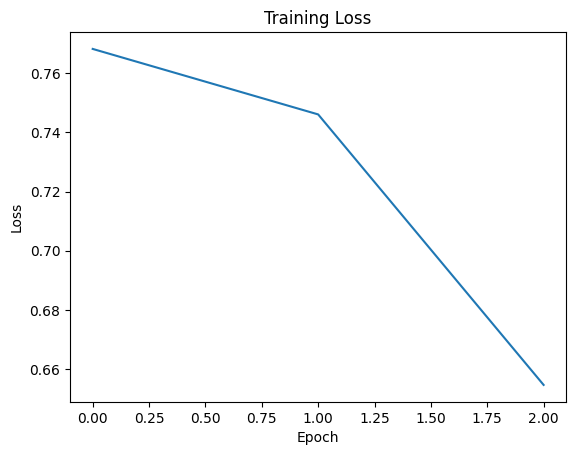

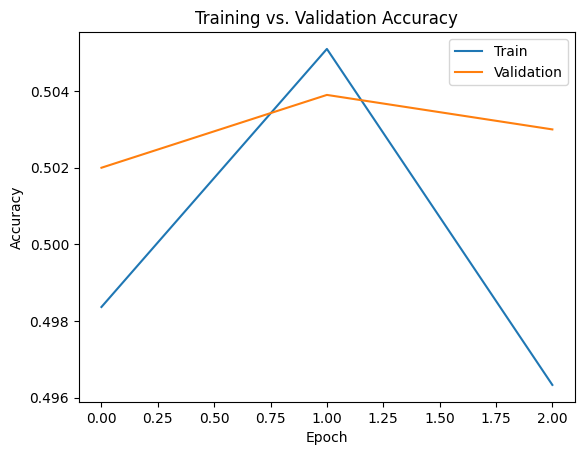

In [26]:
train_data_loader, val_data_loader, test_data_loader = get_dataloaders(16)
model_pooled = SentimentClassifierPooled(n_classes=2).to(device)
train_model(model_pooled, train_data_loader, val_data_loader, learning_rate=0.0001, num_epochs=3)

### Part (iii) [1pt MODEL]

Choose at least 4 hyperparameters to tune. Explain how you tuned the hyperparameters. You don't need to include your training curve for every model you trained.
Instead, explain what hyperparemters you tuned, what the best validation accuracy was,
and the reasoning behind the hyperparameter decisions you made.

For this assignment, you should tune more than just your learning rate and epoch.
Choose at least 2 hyperparameters that are unrelated to the optimizer.

Epoch 1; Loss 0.384304; Train Acc 0.904333; Val Acc 0.843900
Epoch 2; Loss 0.174005; Train Acc 0.971733; Val Acc 0.839500
Epoch 3; Loss 0.009952; Train Acc 0.988300; Val Acc 0.839400


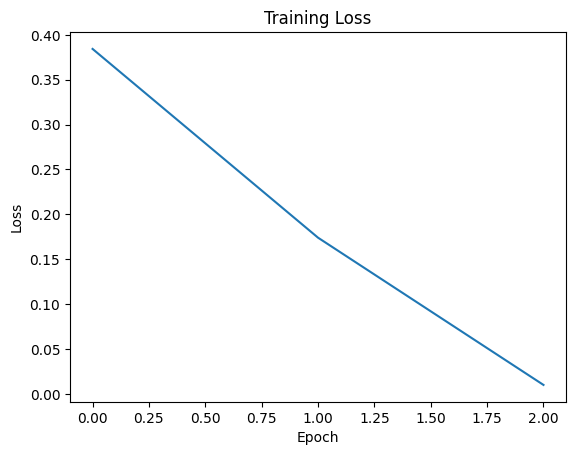

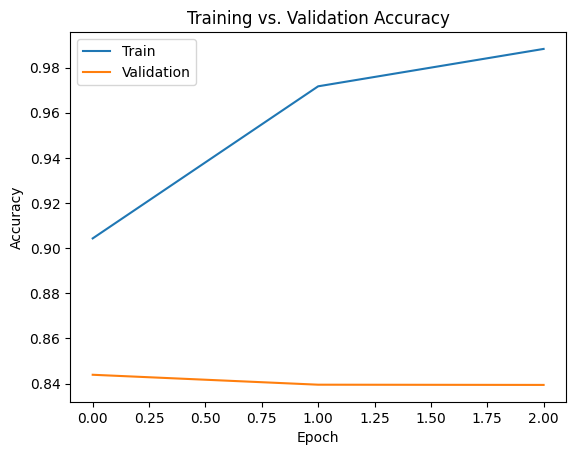

In [27]:
# TO BE COMPLETED

# Best Hyperparamaters obtained after tuning the hyperparameters are as follows:
# Model- SentimentClassifierPooled, Learning_rate = 1e-5, Batch_size = 16, epoch = 3, maximum_length = 75, and dropout = 0.3
train_data_loader_bert, val_data_loader_bert, test_data_loader_bert = get_dataloaders(16, 75)
model_pooled = SentimentClassifierPooled(n_classes=2).to(device)
train_model(model_pooled, train_data_loader_bert, val_data_loader_bert, learning_rate=1e-5, num_epochs=3)


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The hyperparameters selected for tuning are:

Learning rate: We were able to observe that in this case when the learning rate was decreased, the model started to perform pretty good.
This can be because of small gradient steps towards the minimum. Our best learning rate was 1e-5.
Best Validation Accuracy: 0.7341

Batch size: Ierations were conducted to determine a best combination of learning rate and batch size.
Only  batch sizes of 16 and 32 were tested. The others consumed a lot of memory and was too time consuming. Out of those the best Batch Size was found to be 16
Best Validation Accuracy: 0.6879

Maximum Sequence Length:  The determination of a maximum length of 75 was influenced by the average
length of movie reviews, and computational efficiency so that not a lot of information is lost.
Best Validation Accuracy: 0.5912

Dropout rate of 0.3 was chosen to prevent against overfitting by randomly deactivating connections during training.

Model type: Out of the two, Bert model 'SentimentClassifierPooled' and a review classifier model that uses the last hidden output from the Bert model 'SentimentClassifierLast',
the SentimerntClassifierPooled proved to be the best providing greater validation accuracy.
Best Validation Accuracy: 0.7782

'''

## Part 4. Evaluation [10 pt]

### Part (i) [3pt RESULT]

Report the final test accuracy of your best BERT-based model. Then summarize in a pandas dataframe the accuracy obtained on the training, validation, and test data of your best models from Part A and B.

How does the BERT model compare to the approach in part A using only LSTM? Are the results what you expected? Explain.



In [28]:
# TO BE COMPLETED
accuracy_bert = get_accuracy(model_pooled, test_data_loader_bert)
print("The final test accuracy of the best BERT-based model:", accuracy_bert)


The final test accuracy of the best BERT-based model: 0.8367


In [30]:
results_dict = {"Model": ["RNN - Part A",
                          "RNN - Part A",
                          "RNN - Part A",
                          "Bert - Part B",
                          "Bert - Part B",
                          "Bert - Part B"],
               "Dataset": ["Training",
                           "Validation",
                           "Test",
                           "Training",
                           "Validation",
                           "Test"],
               "Accuracy": ['87.18%',
                            '79.32%',
                            '79.92%',
                            '98.83%',
                            '83.94%',
                            '83.67%']
                }
results_df= pd.DataFrame(results_dict)
results_df


,Model,Dataset,Accuracy
0,RNN - Part A,Training,87.18%
1,RNN - Part A,Validation,79.32%
2,RNN - Part A,Test,79.92%
3,Bert - Part B,Training,98.83%
4,Bert - Part B,Validation,83.94%
5,Bert - Part B,Test,83.67%


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The final test accuracy of the best BERT-based model is 0.8367.

In Part B, the BERT model outperforms the RNN model from Part A across all datasets—training, validation, and test.
The BERT model achieves a test accuracy of 0.8367 and thereby showcasing higher capacity to generalize unseen data and capture complex patterns and subtle
meanings in movie reviews. The improvement in accuracy can be attributed to BERT's contextualized word embeddings and its ability to grasp the
context and relationships between words in a sentence.

'''

### Part (ii) [2pt RESULT]

Report the false positive rate and false negative rate of your model across the test set. Then summarize in a pandas dataframe the false postive and false negative rate of your model obtained on the training, validation, and test data of your best models from Part A and B.

How does the BERT model compare to the approach in part A using only LSTM? Are the results what you expected? Explain.

In [31]:
# TO BE COMPLETED
from sklearn.metrics import confusion_matrix

def calc_bert(model, loader):
  model.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for batch in loader:
      inputs = batch['input_ids'].to(device)
      attention_mask = batch['attention_mask'].to(device)
      labels = batch['targets'].to(device)

      output = model(inputs, attention_mask)
      pred = output.max(1, keepdim=True)[1]

      all_preds.extend(pred.cpu().numpy())
      all_labels.extend(labels.cpu().numpy())

  confusion_mat = confusion_matrix(all_labels, all_preds)

  tn, fp, fn, tp = confusion_mat.ravel()

  fpr = fp / (fp + tn)
  fnr = fn / (fn + tp)

  return fpr, fnr

fpr_train_bert, fnr_train_bert = calc_bert(model_pooled, train_data_loader_bert)
fpr_val_bert, fnr_val_bert = calc_bert(model_pooled, val_data_loader_bert)
fpr_bert, fnr_bert = calc_bert(model_pooled, test_data_loader_bert)

print(f'False Positive Rate: {fpr_bert:.3f}')
print(f'False Negative Rate: {fnr_bert:.3f}')



False Positive Rate: 0.161
False Negative Rate: 0.164


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The false positive rate and false negative rate of the best Bert model across the test set are:
False Positive Rate: 0.161
False Negative Rate: 0.164


'''

### Part (iii) [3pt DISCUSSION]
Examine some of the misclassified reviews from you best BERT and LSTM models to better identify the differences in the models. Try to provide some justification for any differences in the misclassifications observed in the models.

Is there any part of the review that you could modify to make the classifications correct? Try to make small changes to the review to see if you can make the model make the correct classification while keeping the review as close to the original as possible.

In [ ]:
# TO BE COMPLETED





In [ ]:
'''
PROVIDE YOUR ANSWER BELOW






'''

### Part (iv) [2pt DISCUSSION]
Find 5 samples of positive and negative reviews on IMDB that were posted recently and evaluate them with your best BERT and LSTM models from parts A and B. How well do they perform?

In [32]:
# TO BE COMPLETED

neg1= 'This was so bad I couldn´t finish it. The actresses are so bad at acting it feels like a bad comedy from minute one. The high rated reviews is obviously from friend/family and is pure BS.'
neg2= "This movie is absolutely terrible. The directing, acting, script and production are all bad. There is actually NOTHING redeemable about it. In fact if MY friend was in this movie, instead of giving it a perfect score, I'd stop being friends with them. That's how bad it is. YOU HAVE BEEN WARNED DO NOT WASTE YOUR TIME ON THIS MOVIE."
neg3= "I wanted to like this movie. I really did. But the thing is there is absolutely NOTHING to like about it lol. It's not funny, the acting is horrible, the plot is nonexistent and just nothing about this movie even makes sense. Don't waste your time with this one."


pos1="The actress Kyleigh Bakker who plays the role as Kylie is a well known friend of mine from school and she is extremely talented from singing and of course acting. At school she slayed theater class like it was nothing, and I hope to see more of her and her talent. I know that she'll grow to do big things leading to awards and huge audiences shouting her name, and I'll definitely be there every step of the way, congratulations Kyleigh you earned everything coming to you positively!!!"
pos2= "I thought the cast was great. Brianna and Emma were exceptionaly talented in thier characters. Fun film."
pos3="Worth watching twice, first time for the plot, second time to absorb some of the sharp dialogue. Judging by some of the 1/10 reviews on here I'd say you probably have to be over the age of 16 and an IQ above 80 to appreciate some of the irony, or the reviewrs just like releasing some of their angst online. It's interesting to note that the most liked review, a 1/10, was given by someone with 87% 1/10 reviews! Form your own conclusions about that! Brianna Roy has a bit of a Reese Witherspoon thing going on about her."


In [33]:
def get_pred(text, model):
  tokenized_input = tokenizer(text, return_tensors='pt', max_length=75, truncation=True)
  input_ids = tokenized_input['input_ids'].to(device)
  attention_mask = tokenized_input['attention_mask'].to(device)
  with torch.no_grad():
    logits = model(input_ids, attention_mask)

  probabilities = torch.nn.functional.softmax(logits, dim=1)
  predicted_class = torch.argmax(probabilities, dim=1).item()
  if predicted_class == 0:
    label = "Negative"
  else:
    label = "Positive"
  print(f"Predicted Class: {predicted_class}({label})")

In [34]:
print("Bert Model Prediction")
print("Negative Reviews")

get_pred(neg1, model_pooled)
get_pred(neg2, model_pooled)
get_pred(neg3, model_pooled)


print("\nPositive Reviews")

get_pred(pos1, model_pooled)
get_pred(pos2, model_pooled)
get_pred(pos3, model_pooled)


Bert Model Prediction
Negative Reviews
Predicted Class: 0(Negative)
Predicted Class: 0(Negative)
Predicted Class: 0(Negative)

Positive Reviews
Predicted Class: 1(Positive)
Predicted Class: 1(Positive)
Predicted Class: 1(Positive)


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

We can see that our model is able to correctly verify and find the sentiments in reviews and classify it as possible or negative



'''

# PART C (Optional) - Bonus Challenge!

This is an optional exercise for those that finish the assignment early and would like to take on a challenging task.

In part A we constructed and trained an LSTM model to identify the sentiment in movie reviews. In Part B we used the embeddings of a BERT model pretrained on a large corpus of text to demonstrate how transfer learning can be used to improve our movie sentiment model. The BERT model is one of many language models that we could have used to implement transfer learning.

For this bonus challenge you are asked to implement a generative character-level LSTM model to produce IMDB movie reviews. Once the model is sufficiently trained you can then use its hidden states as the embedding for training a movie sentiment model. Construct your new movie sentiment analysis model and compare the performance against the model from part A and B.

There are many variants of a generative LSTM model that you can consider. As a starting point you can use the generative LSTM sample code provided in the lecture notes. Specifically, the one used to generate Shakeaspeare. More advanced versions of a generative LSTM can be found in the Universal Language Model Fine-turing for Text Classification (ULMfit) paper (https://arxiv.org/abs/1801.06146).

Tasks:

1. Create a generative character-level LSTM model trained to create IMDB reviews
2. Create a classifier using the embeddings from the generative LSTM model (from step 1) to identify positive and negative reviews.
3. Compare the performance of the model with the results in parts A and B of the assignment.
4. Upgrade the generative LSTM model using the techniques listed in the ULMfit paper (e.g., bi-directional LSTM, pretraining with wikipedia text and fine-tuning on IMDBT reviews, etc.).

Bonus marks will be provided based on the number of steps completed. Summarize below your results and anything intersting you learned from the steps that you completed. Bonus marks cannot be accumulated beyond a maximum assignment grade.


In [ ]:
# TO BE COMPLETED




In [ ]:
'''
PROVIDE YOUR ANSWER BELOW






'''

### Saving to HTML
Detailed instructions for saving to HTML can be found <a href="https://stackoverflow.com/questions/53460051/convert-ipynb-notebook-to-html-in-google-colab/64487858#64487858">here</a>. Provided below are a summary of the instructions:

(1) download your ipynb file by clicking on File->Download.ipynb

(2) reupload your file to the temporary Google Colab storage (you can access the temporary storage from the tab to the left)

(3) run the following:

In [ ]:
#!pip install nbconvert

%%shell
jupyter nbconvert --to html /content/A4.ipynb


[NbConvertApp] Converting notebook /content/A4.ipynb to html
[NbConvertApp] Writing 679783 bytes to /content/A4.html


(4) the html file will be available for download in the temporary Google Colab storage

(5) review the html file and make sure all the results are visible before submitting your assignment to Quercus

# Assignment Grading Rubric
The grading of the assignment will be based on the following categories:

(1) **10 Pt - EXPLORATORY QUESTIONS** These are basic questions that in most cases can be answered without requiring a fully working and trained neural network model. For example, data loading, processing and visualization, summary statistics, data exploration, model and training setup, etc.

(2) **10 Pt - MODEL** Student has successfully implemented all the required neural network models and has demonstrated successful training of the model without any errors.

(3) **10 Pt - RESULT** Students are evaluated based on the results achieved in comparison to the expected results of the assignment.

(4) **10 Pt - DISCUSSION QUESTIONS** Student demonstrated understanding beyond the basic exploratory questions, can answer some of the more challenging questions, and provide arguments for their model selection decisions.

(5) **10 Pt - COMMUNICATION** Student has provided a quality submission that is easy to read without too many unnecessary output statements that distract the reading of the document. The code has been well commented and all the answers are communicated clearly and concisely.

(6) **10 Pt - BONUS** Student has completed the assignment and has taken on the challenging bonus tasks listed in PART C. The student has demonstrated a good understanding of all aspects of the assignment and has exceeded expectations for the assignment.



**TOTAL GRADE = _____ of 50 Pts**